In [12]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
def f(x):
  return 3*x**2 -4*x + 5

In [14]:
f(3.0)

20.0

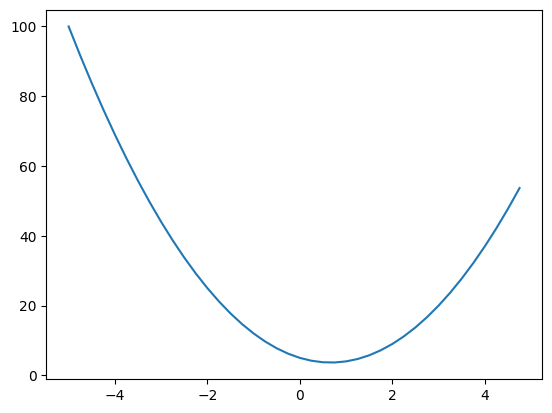

In [15]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [16]:
h = 0.001
x = 3
(f(x+h)-f(x))/h

14.00300000000243

In [17]:
h = 0.000000001
x = 2/3
(f(x+h)-f(x))/h

0.0

In [18]:
# let get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [19]:
h = 0.001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a+=h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.997
slope -3.0000000000001137


In [20]:
class Value:

  def __init__(self, data, children = (), _op = '', label = ''):
    self.data = data
    self.grad = 0
    self._prev = set(children)
    self._backward = lambda: None
    self._op = _op
    self.label = label

  def __repr__(self):
    return f'Value(data={self.data})'

  def __add__(self, other):

    other = other if isinstance(other, Value) else Value(other)

    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward

    return out

  def __radd__(self, other):
    return self + other

  def __mul__(self, other):

    other = other if isinstance(other, Value) else Value(other)

    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward

    return out

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1

  def __neg__ (self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def __pow__(self, other):

    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
      self.grad += (other * self.data**(other-1)) * out.grad

    out._backward = _backward

    return out

  def tanh(self):

    out = Value(math.tanh(self.data), (self,), 'tanh')

    def _backward():
      self.grad += (1 - out.data**2) * out.grad

    out._backward = _backward

    return out

  def exp(self):
    out = Value(math.exp(self.data), (self,), 'exp')

    def _backward():
      self.grad += out.data * out.grad

    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    self.grad = 1

    for node in reversed(topo):
      node._backward()

In [21]:
a = Value(2)
b = Value(4)
c = a / b
c.backward()
# draw_dot(c)

In [22]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      dot.node(name = uid + n._op, label = n._op)
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

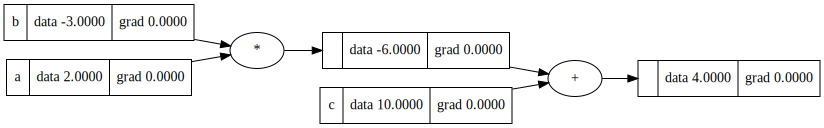

In [23]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

d = a*b + c
d._prev

draw_dot(d)

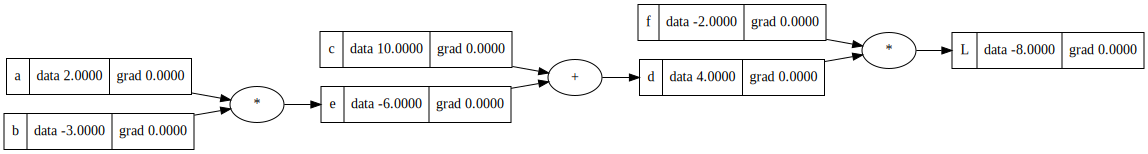

In [24]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L
draw_dot(L)

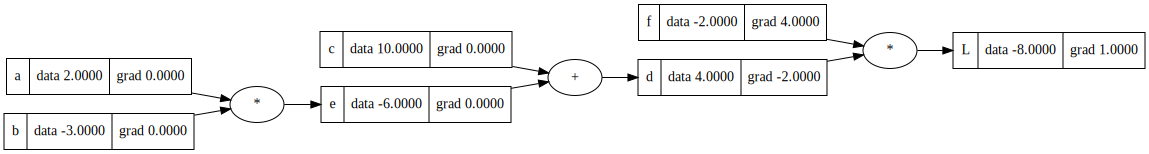

In [25]:
L.grad = 1
f.grad = 4.0
d.grad = -2
draw_dot(L)

dl / dc = dl/dd * dd/dc = 1 * -2

dl / de = dl/dd * dd/de = 1 * -2

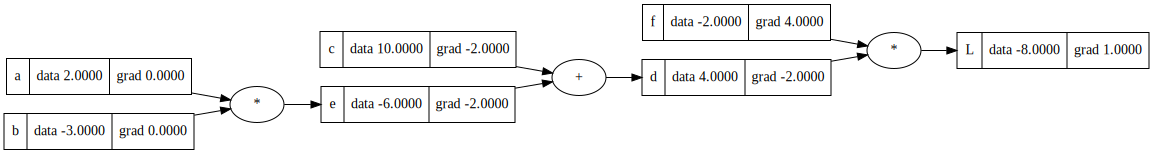

In [26]:
c.grad = -2
e.grad = -2
draw_dot(L)

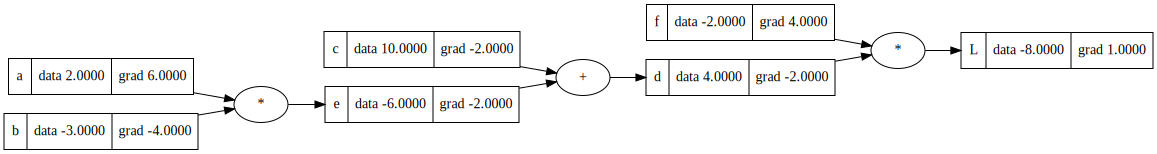

In [27]:
b.grad = -2 * 2
a.grad = -3 * -2
draw_dot(L)

In [28]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b
d = e + c
L = d * f
print(L)



Value(data=-7.286496)


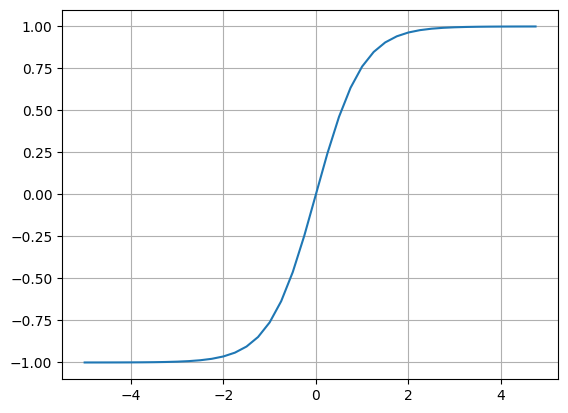

In [29]:
plt.plot(np.arange(-5, 5, 0.25),np.tanh(np.arange(-5, 5, 0.25)))
plt.grid()

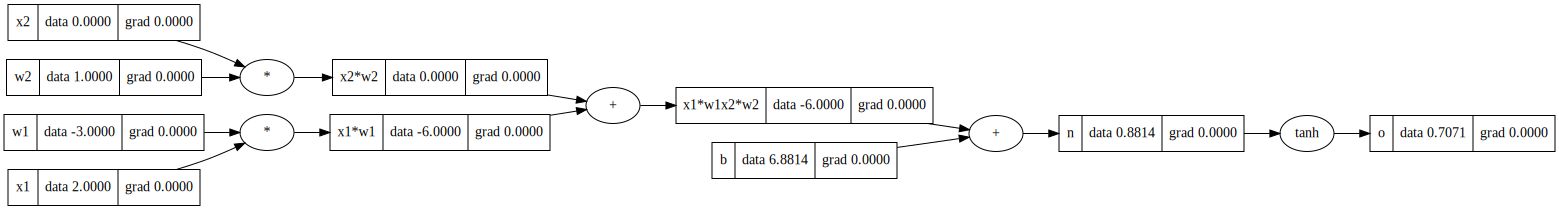

In [30]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

#outut
o = n.tanh(); o.label = 'o'

draw_dot(o)

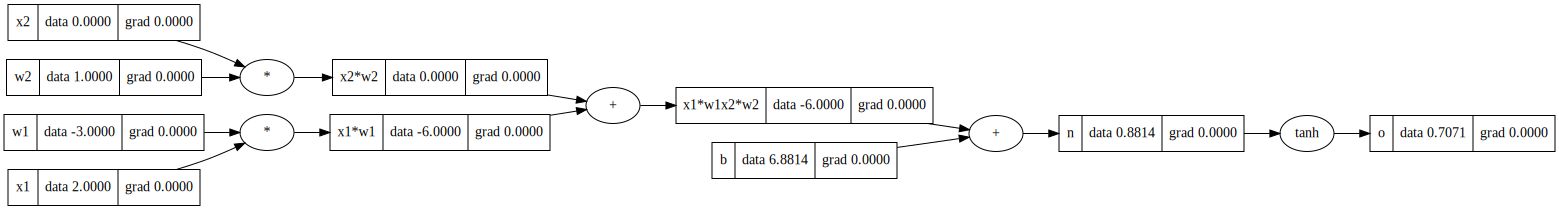

In [31]:
draw_dot(o)

In [32]:
o.backward()

In [33]:
o.grad = 1

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)

build_topo(o)

for node in reversed(topo):
  node._backward()

In [34]:
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

In [35]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [36]:
w2.grad = x2.data * x2w2.grad
x2.grad = w2.data * x2w2.grad

In [37]:
x2w2.grad = x1w1x2w2.grad
x1w1.grad = x1w1x2w2.grad

In [38]:
x1w1x2w2.grad = n.grad

In [39]:
b.grad = n.grad

In [40]:
n.grad = 0.5

In [41]:
o.grad = 1

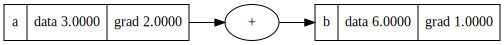

In [42]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

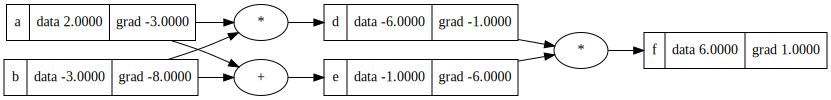

In [43]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)


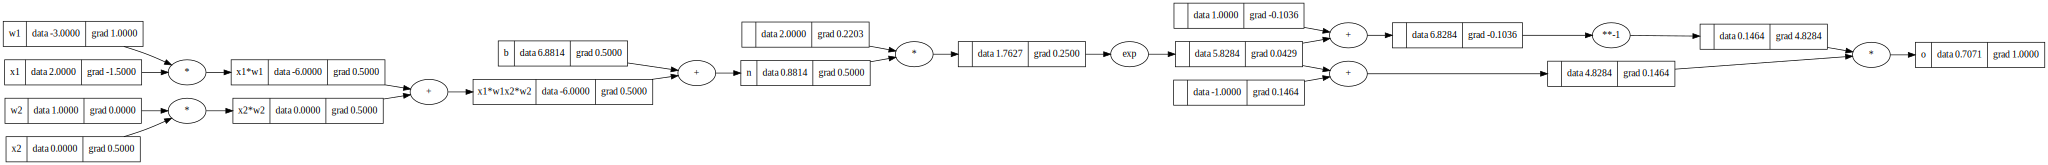

In [44]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

#outut
# o = n.tanh(); o.label = 'o'

# -----
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
# -----

o.backward()

draw_dot(o)

In [45]:
import torch

In [46]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [47]:
torch.Tensor([2.0]).double()

tensor([2.], dtype=torch.float64)

开始定义单个神经元

In [48]:
import random

In [63]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):

    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [50]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=0.4551263671847177)

In [51]:
x = [2.0, 3.0]
l = Layer(2, 3)
l(x)

[Value(data=-0.9962216323428014),
 Value(data=0.9955298491995995),
 Value(data=0.5815665832985999)]

In [64]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
r = n(x)

In [133]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9999461546979281),
 Value(data=-0.994336522845113),
 Value(data=-0.9922371162035818),
 Value(data=0.9999358071863371)]

In [134]:
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=9.23443583545007e-05)

In [131]:
loss.backward()

In [132]:
ps = n.parameters()

for p in ps:
  p.data += -0.01*p.grad

In [137]:
for k in range(200):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

  # backward pass
  for p in ps:
    p.grad = 0.0
  loss.backward()

  # update
  for p in ps:
    p.data += -0.05*p.grad

  print(k, loss.data)

0 9.166316549195413e-05
1 9.162937080012459e-05
2 9.159560113584594e-05
3 9.156185647128307e-05
4 9.152813677863861e-05
5 9.149444203015466e-05
6 9.146077219811994e-05
7 9.142712725485604e-05
8 9.139350717273543e-05
9 9.135991192416599e-05
10 9.132634148159602e-05
11 9.129279581751492e-05
12 9.125927490445478e-05
13 9.12257787149866e-05
14 9.119230722172076e-05
15 9.115886039731187e-05
16 9.112543821445384e-05
17 9.109204064587667e-05
18 9.105866766435647e-05
19 9.102531924270568e-05
20 9.099199535377691e-05
21 9.095869597046743e-05
22 9.092542106570578e-05
23 9.08921706124701e-05
24 9.085894458377234e-05
25 9.082574295266589e-05
26 9.079256569224082e-05
27 9.075941277563328e-05
28 9.07262841760147e-05
29 9.069317986659323e-05
30 9.066009982062235e-05
31 9.06270440113902e-05
32 9.059401241223084e-05
33 9.056100499650411e-05
34 9.052802173762635e-05
35 9.049506260903778e-05
36 9.04621275842267e-05
37 9.042921663671536e-05
38 9.039632974006878e-05
39 9.036346686788862e-05
40 9.0330627993

In [138]:
ypred

[Value(data=0.9999459687773551),
 Value(data=-0.994554618782717),
 Value(data=-0.9925341933773515),
 Value(data=0.9999355587530039)]